# Let us apply the latest optimisation code to Hattie's latest data set

In [1]:
%run -i preambles
%run -i helper_functions
%run -i fitting_functions

In [2]:
# # Global parameters:
number_of_cycles = 500 # how many passes through the training data we go through
number_of_groups = 1 # divide the data set into smaller ones, to make fitting easier.
steps_per_batch = 5
dims = 2  # 2D spatial
head = 0 # how many locations to consider in the real data set.

# for synthetic data
# locations_per_group = 200 # how many locations to observe per group
# number_of_locations = number_of_groups * locations_per_group # total locations
# number_of_simulations = 300 # for synthetic data, how many optimisation to average over
# p =  3 # how many features 

In [3]:
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
# puck_list = ['Puck_230223_01', 'Puck_230406_01', 'Puck_230406_06', 'Puck_230406_08', 
#              'Puck_230517_37', 'Puck_230517_38', 'Puck_230517_39', 'Puck_230913_07', 
#              'Puck_240108_20', 'Puck_240108_24', 'Puck_240108_25', 'Puck_240108_26', 
#              'A0029_047', 'A0029_043', 'Puck_230807_27', 'Puck_240129_36', 'Puck_240129_37', 
#              'A0029_042', 'A0029_036', 'PM104_004', 'Puck_240108_10', 'Puck_240108_11', 
#              'Puck_230807_04', 'Puck_230714_28', 'Puck_230714_23']
# puck_list = ['Puck_230517_39'] # the largest puck
puck_list = 'all'
adata, X,Y,df=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
df

,x,y,Inha,Inhba,Inhbb,Fst,Esr1,Esr2,Pgr,Ar,...,Fshr,Star,Ptgfr,Sfrp4,Acvr1,Acvr2a,Acvr2b,Ghr,Lhb,Cga
CCGGGACATAGAGT-1-0,1.576981,0.908701,1.961749,0.000000,3.524486,11.787981,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
GGAAACTCGTATCG-1-1,1.267764,0.724246,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,2.126029,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
CTGCTCATGACAGG-1-1,1.005131,0.570030,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
ACGCGCGCCGCGAC-1-1,1.081355,0.882246,4.904372,2.354596,0.000000,23.575962,0.0,73.214447,0.0,6.442922,...,70.831398,0.000000,0.000000,0.0,0.000000,0.0,0.0,478.616302,0.0,0.0
TTGGGTCCCCGGTN-1-2,1.408364,1.038135,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,11.395626,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGCCCAGTATCGCG-1-2,0.783950,0.702267,1.961749,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
AACAATAGACATAC-1-1,0.647595,1.297806,0.980874,0.000000,0.000000,0.000000,0.0,0.000000,0.0,6.442922,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,11.395626,0.0,0.0
TCCGGTTTTCATTA-1-0,1.323982,1.699865,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
TACNCCTAGCTGCT-1-2,0.690561,0.946545,1.961749,0.000000,3.524486,0.000000,0.0,8.134939,0.0,0.000000,...,0.000000,0.000000,20.598263,0.0,15.672419,0.0,0.0,0.000000,0.0,0.0


In [4]:
# def tensor_memory_usage(tensor):
#     # Calculate the memory usage in bytes
#     memory_bytes = tensor.numel() * tensor.element_size()
#     # Convert to MB or GB if needed
#     memory_mb = memory_bytes / (1024 ** 2)  # Convert bytes to megabytes
#     memory_gb = memory_bytes / (1024 ** 3)  # Convert bytes to gigabytes
    
#     return memory_bytes, memory_mb, memory_gb

# tensor_memory_usage(X)

In [5]:
# df.memory_usage().sum()/ (1024 ** 2)

In [6]:
# df["Lhb"].value_counts()

In [7]:
# # code for checking if a gene actually exists.
# gene_name = "Cga"
# matching_genes = [gene for gene in adata.raw.var_names if gene_name in gene]
# if matching_genes:
#     print(f"{gene_name} is found in the following gene names: {matching_genes}")
# else:
#     print(f"{gene_name} is not part of any gene names.")

In [8]:
unique_values = adata.obs["puck"].unique()
counts = adata.obs["puck"].value_counts()

print("Unique values:", list(unique_values))
print("Counts for each unique value:", counts)

Unique values: ['Puck_230223_01', 'Puck_230406_01', 'Puck_230406_06', 'Puck_230406_08', 'Puck_230517_37', 'Puck_230517_38', 'Puck_230517_39', 'Puck_230913_07', 'Puck_240108_20', 'Puck_240108_24', 'Puck_240108_25', 'Puck_240108_26', 'A0029_047', 'A0029_043', 'Puck_230807_27', 'Puck_240129_36', 'Puck_240129_37', 'A0029_042', 'A0029_036', 'PM104_004', 'Puck_240108_10', 'Puck_240108_11', 'Puck_230807_04', 'Puck_230714_28', 'Puck_230714_23']
Counts for each unique value: puck
Puck_230517_39    15907
Puck_230406_08    14291
PM104_004         12694
Puck_230406_01    11756
Puck_240129_37    10794
Puck_230517_37    10570
Puck_230406_06     9913
A0029_043          9454
Puck_230807_04     8899
Puck_230807_27     8847
Puck_230223_01     8371
Puck_230913_07     7327
Puck_240129_36     6789
Puck_240108_10     6608
Puck_230714_23     6469
A0029_047          6448
A0029_042          6430
Puck_240108_26     6154
Puck_240108_25     5819
Puck_230517_38     5779
Puck_240108_11     5432
Puck_240108_24     5

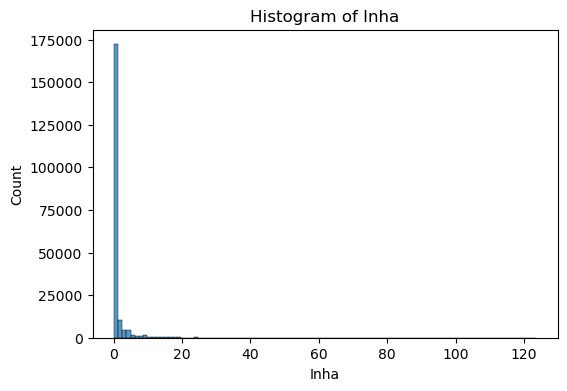

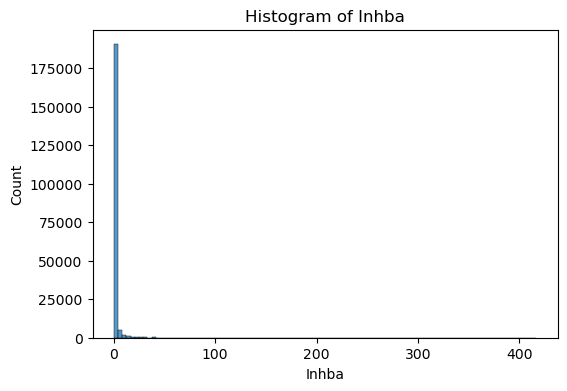

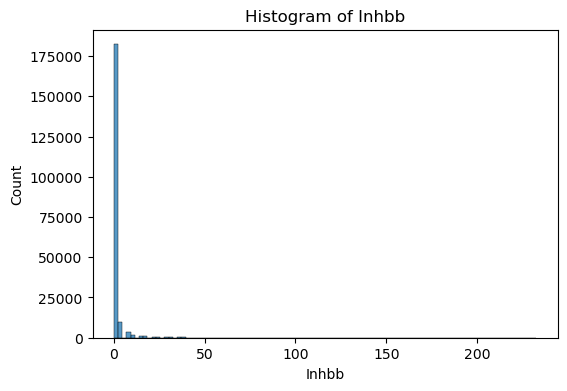

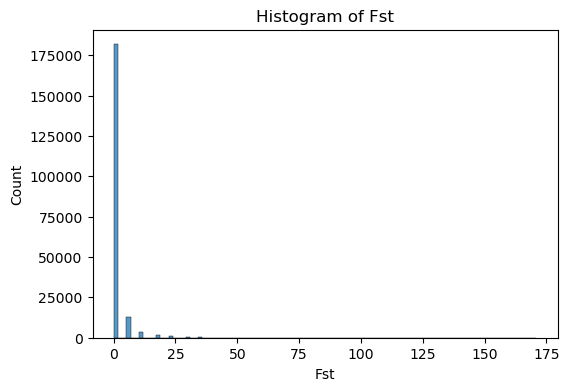

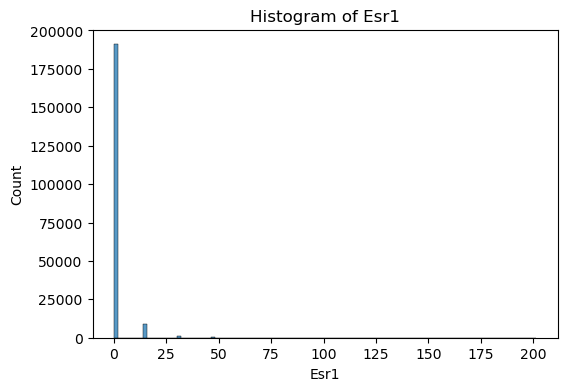

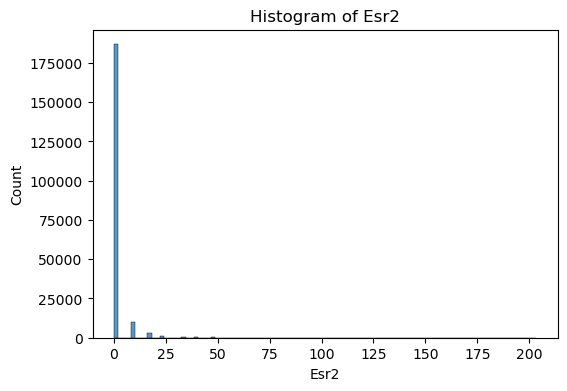

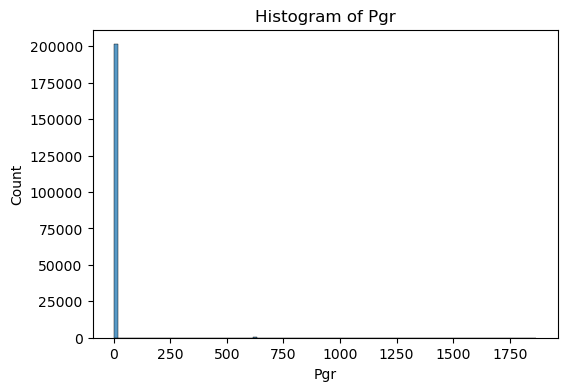

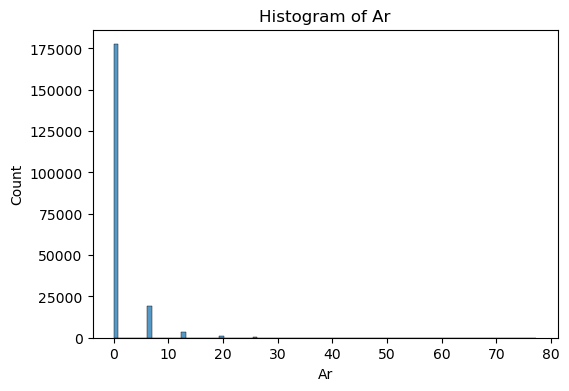

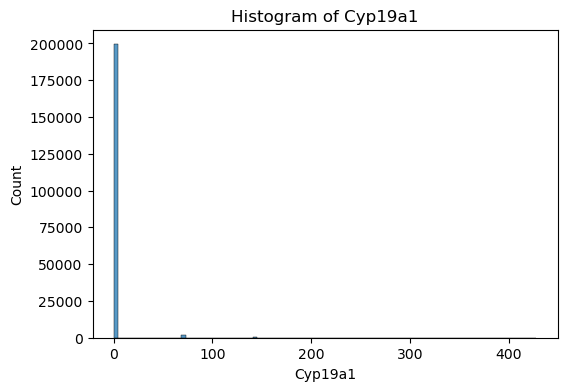

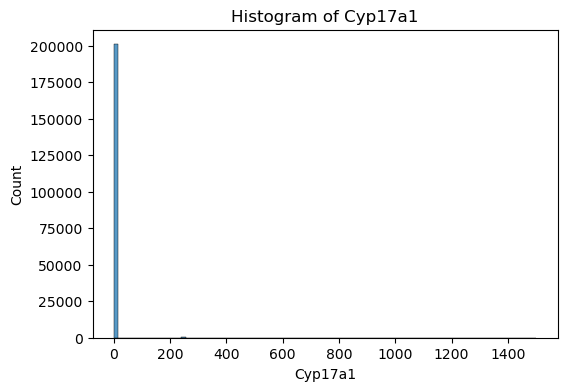

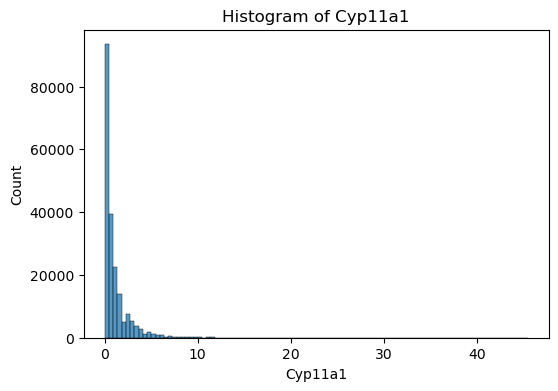

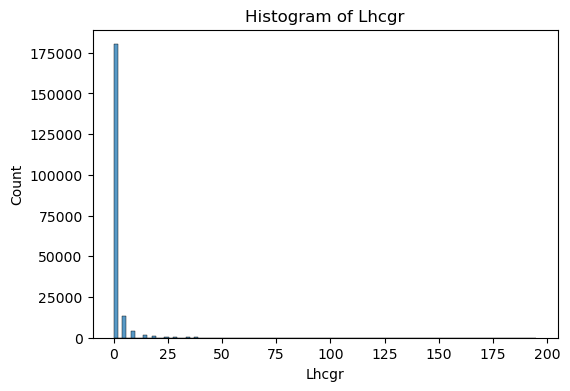

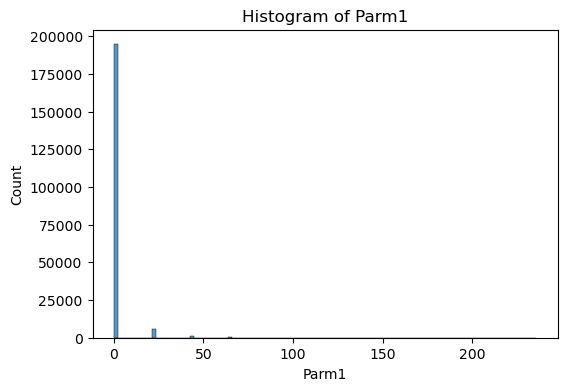

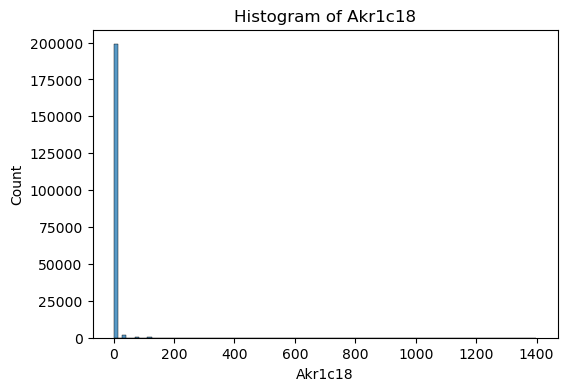

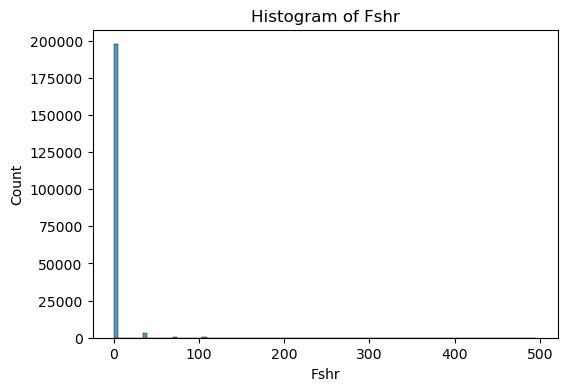

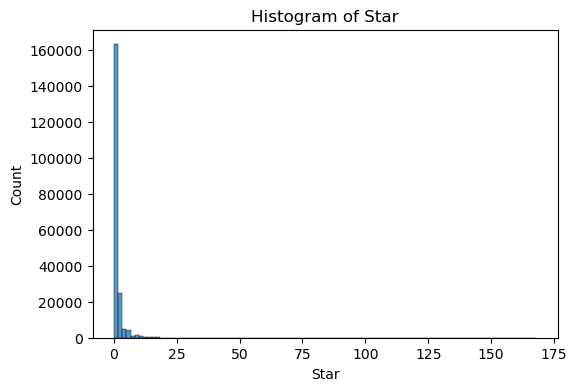

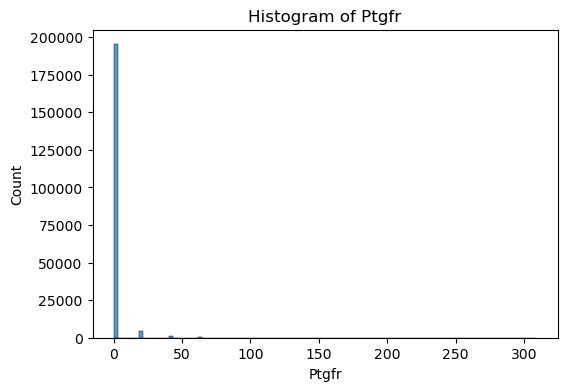

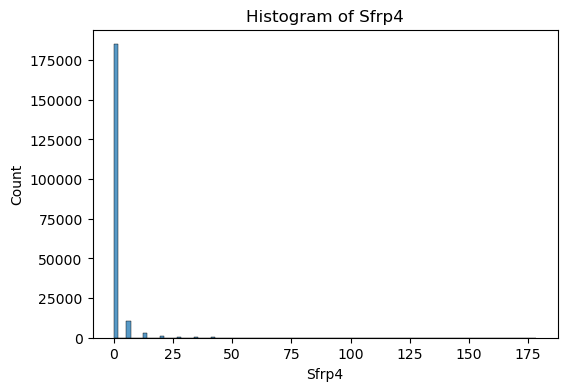

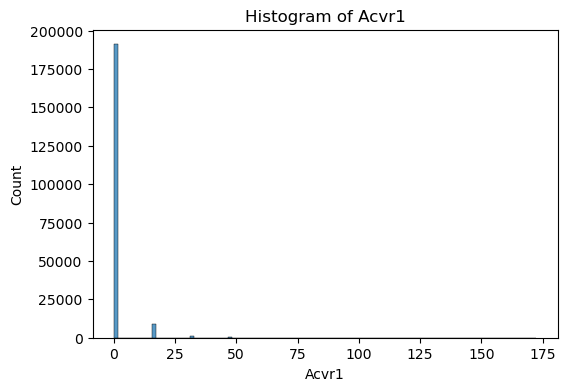

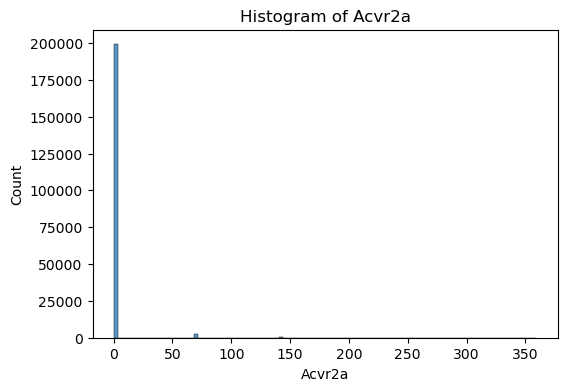

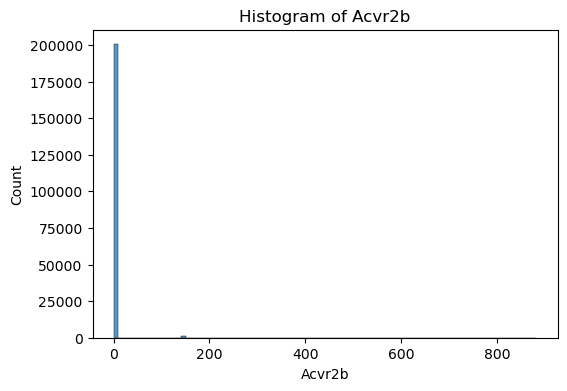

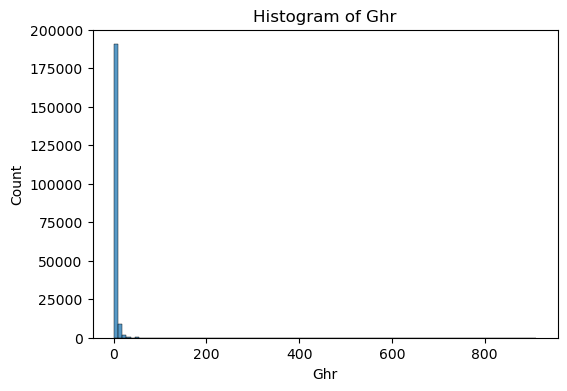

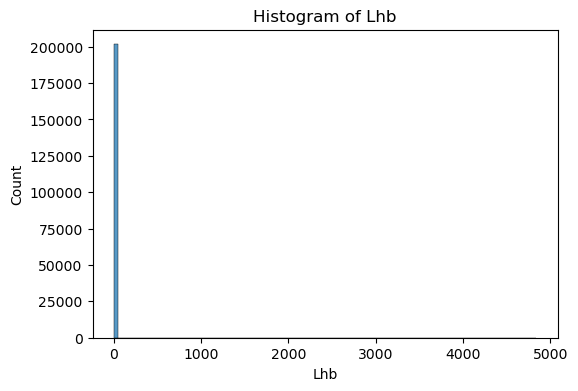

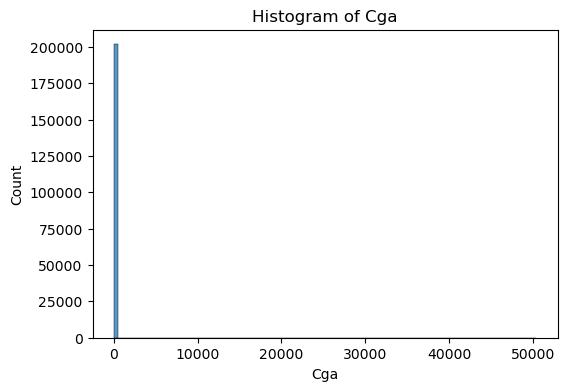

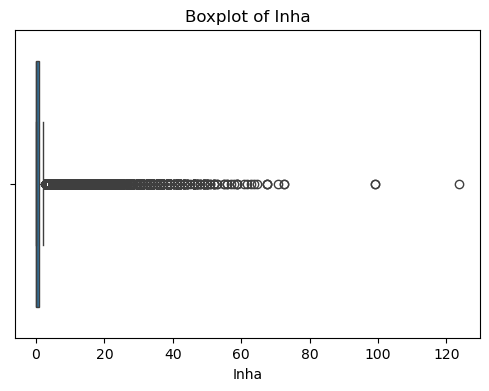

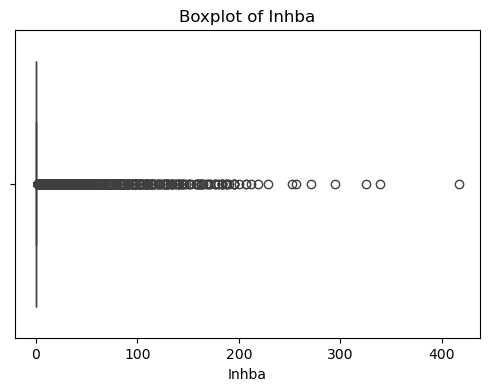

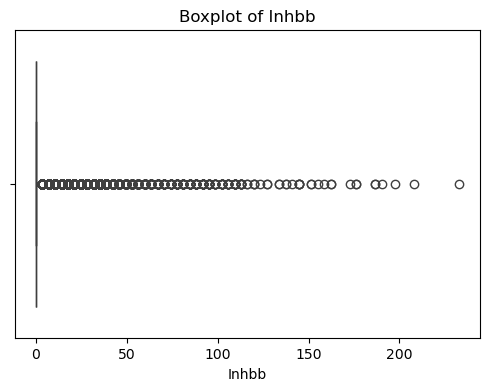

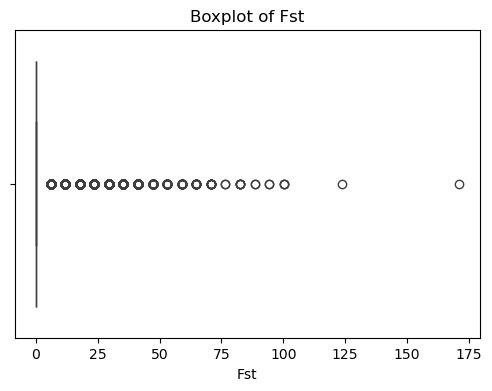

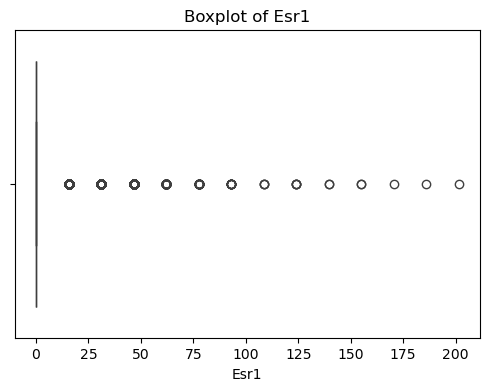

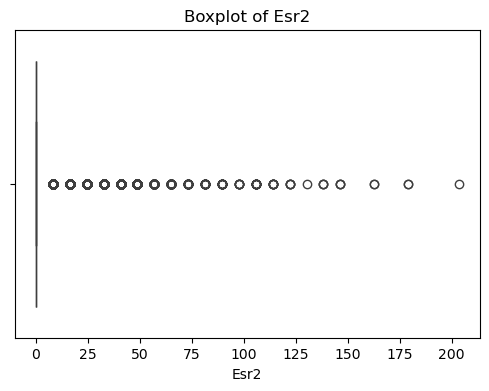

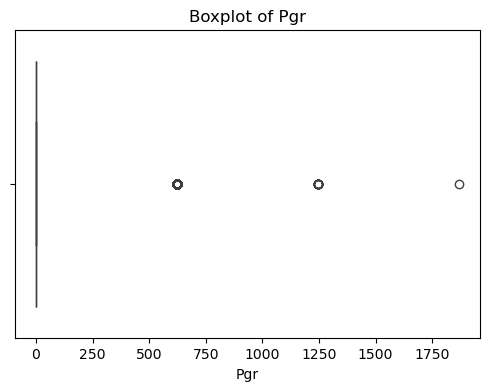

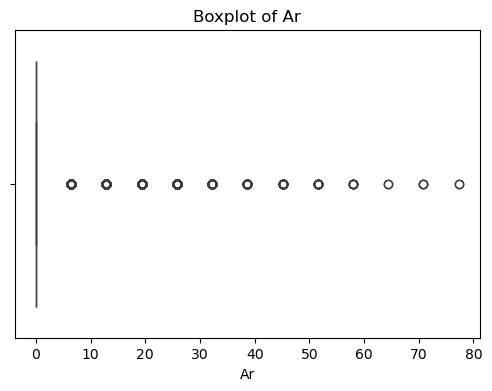

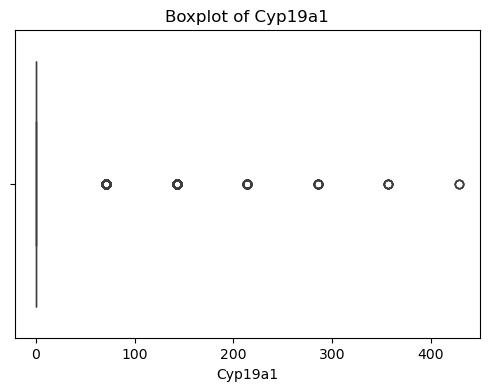

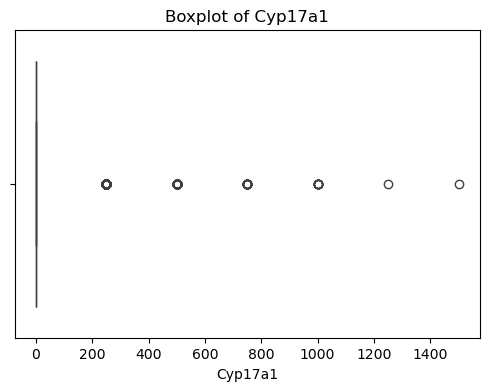

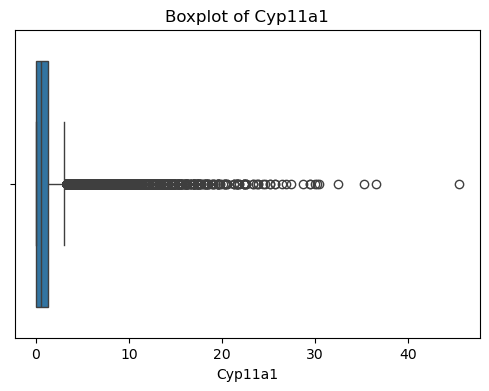

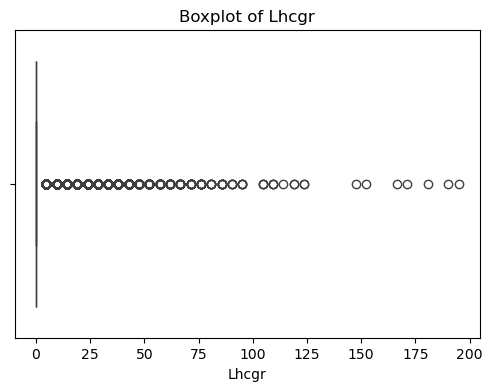

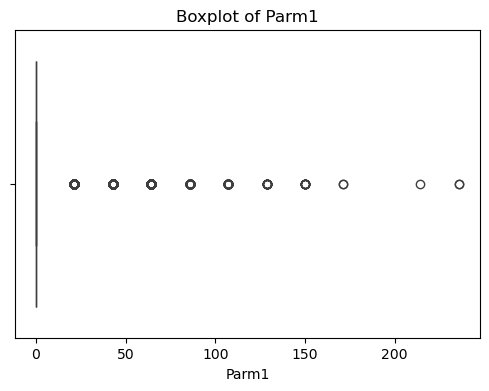

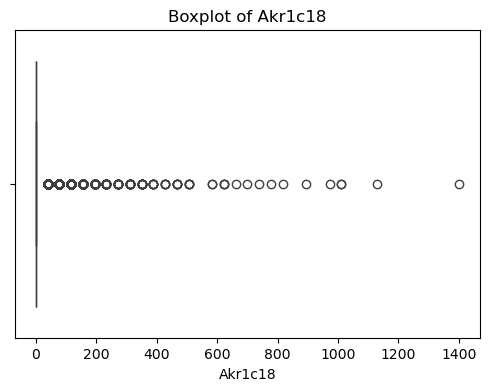

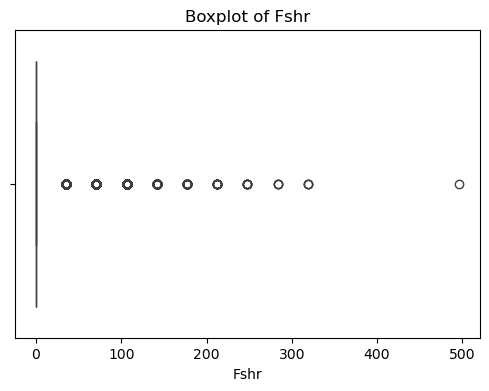

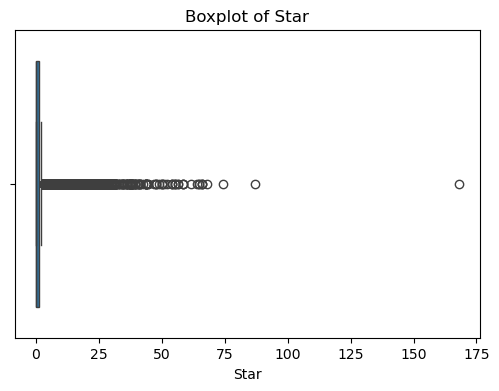

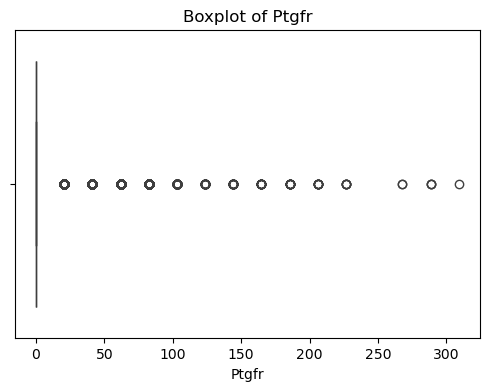

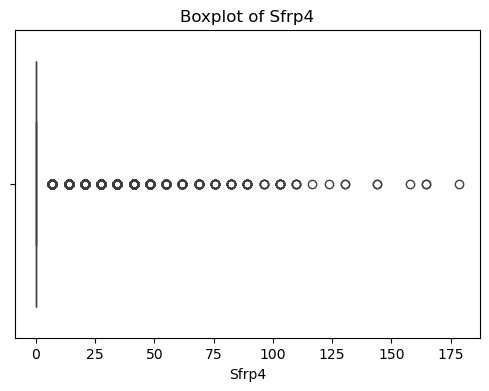

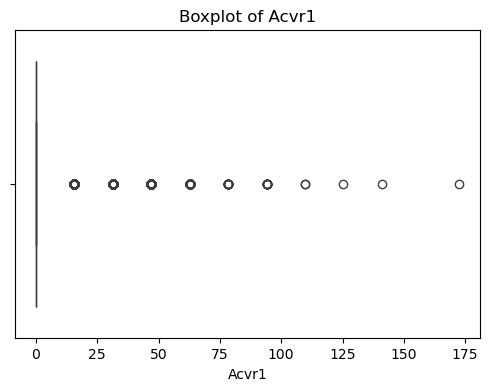

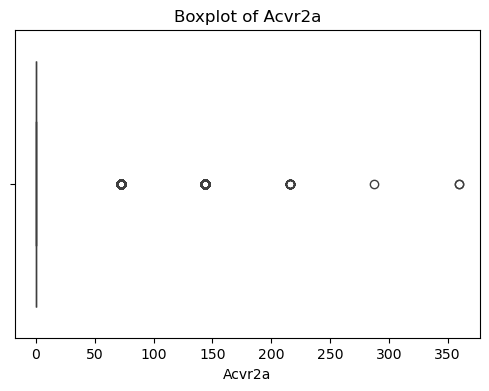

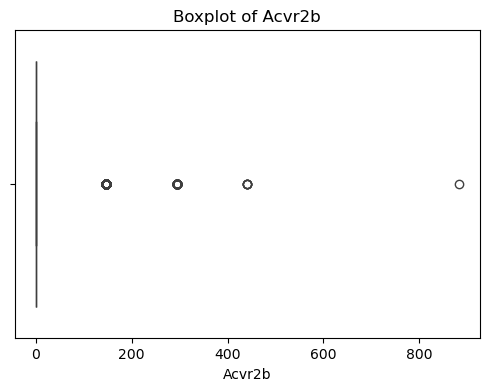

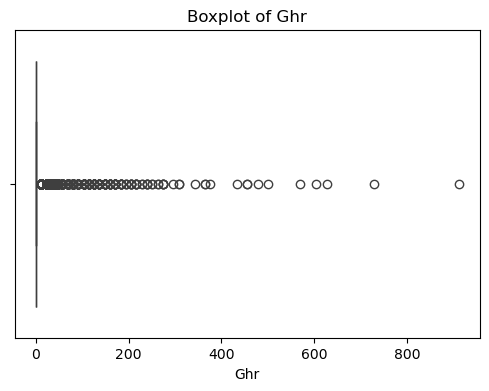

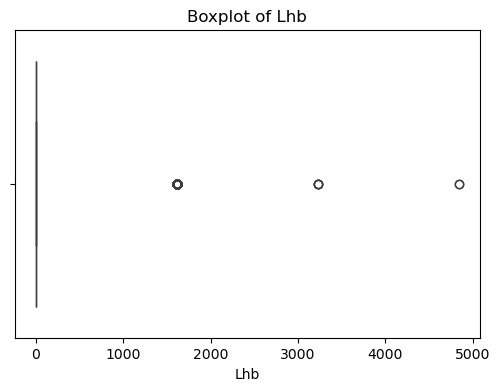

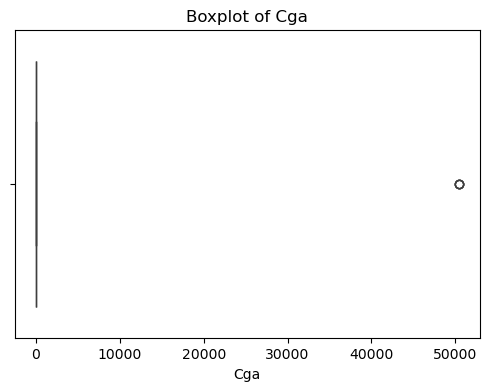

             Inha     Inhba     Inhbb       Fst      Esr1      Esr2       Pgr  \
Inha     1.000000  0.428439  0.405003  0.383866  0.033333  0.310765 -0.001162   
Inhba    0.428439  1.000000  0.498032  0.399470 -0.009511  0.282906  0.001710   
Inhbb    0.405003  0.498032  1.000000  0.400276 -0.012002  0.241525 -0.004357   
Fst      0.383866  0.399470  0.400276  1.000000 -0.008178  0.271435 -0.000585   
Esr1     0.033333 -0.009511 -0.012002 -0.008178  1.000000  0.016938  0.012362   
Esr2     0.310765  0.282906  0.241525  0.271435  0.016938  1.000000  0.002593   
Pgr     -0.001162  0.001710 -0.004357 -0.000585  0.012362  0.002593  1.000000   
Ar       0.180467  0.136148  0.140403  0.150783  0.059845  0.129544  0.008840   
Cyp19a1  0.170547  0.230310  0.227880  0.180581  0.003290  0.133852 -0.001783   
Cyp17a1  0.026894  0.030001  0.020451  0.016365  0.012709  0.037138  0.002228   
Cyp11a1 -0.048523 -0.151246 -0.129549 -0.051905  0.093719 -0.173510 -0.000286   
Lhcgr    0.044311 -0.005191 

In [9]:
### Exploratory Data Analysis
# Plot histograms
for gene in gene_list:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[gene], kde=False, bins=100)
    plt.title(f'Histogram of {gene}')
    plt.show()

# Plot boxplots
for gene in gene_list:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[gene])
    plt.title(f'Boxplot of {gene}')
    plt.show()

# Calculate pairwise Spearman's correlation
spearman_corr = df[gene_list].corr(method='spearman')

# Print the Spearman correlation matrix
print(spearman_corr)

# Assuming spearman_corr is your Spearman correlation matrix
# Set the diagonal to NaN to exclude it from the condition
# np.fill_diagonal(spearman_corr.values, np.nan)

# Filter the off-diagonal values with an absolute value greater than 0.3
off_diagonal_filtered = spearman_corr[(spearman_corr.abs() > 0.3)]

# Get the pairs of features that satisfy the condition
pairs = []
for row in off_diagonal_filtered.index:
    for col in off_diagonal_filtered.columns:
        if row > col:
            if not np.isnan(off_diagonal_filtered.loc[row, col]):
                pairs.append((row, col, off_diagonal_filtered.loc[row, col]))

pairs = sorted(pairs, key=lambda pair: pair[2], reverse=True)

# Print the pairs and their corresponding Spearman correlation values
for pair in pairs:
    print(f"Pair: {pair[0]} and {pair[1]}, Correlation: {pair[2]:.3g}")

In [10]:
# # plot the spatial distribution on the pucks
# # Create a folder to save the figures
# output_folder = "puck_spatial_plots"
# if not os.path.exists(output_folder):
#     os.makedirs(output_folder)

# # Get spatial coordinates
# spatial_coords = adata.obsm["spatial"]

# # Loop through each puck and plot
# puck_labels = adata.obs["puck"].unique()

# for puck in puck_labels:
#     puck_mask = adata.obs["puck"] == puck
#     puck_coords = spatial_coords[puck_mask]
    
#     plt.figure(figsize=(6, 6))
#     plt.scatter(puck_coords[:, 0], puck_coords[:, 1], s=10, alpha=0.6)
#     plt.title(f'Spatial distribution for puck {puck}')
#     plt.xlabel('X coordinate')
#     plt.ylabel('Y coordinate')
#     plt.gca().invert_yaxis()  # Invert the y-axis if necessary for correct orientation
    
#     # Save the plot
#     save_path = os.path.join(output_folder, f"puck_{puck}_spatial_plot.png")
#     plt.savefig(save_path)
#     plt.close()  # Close the figure to avoid display


### The memory tracker

In [11]:
# this block runs the loading and the optimisation steps 
def fitting_codes(head):
    adata, X,Y,df=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
    estimated_params_df = pd.DataFrame()
    distance_K_df = pd.DataFrame()

    torch.autograd.set_detect_anomaly(True)
    optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
    print(optimized_marginal_params)
    alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
    # estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
    # distance_K = torch.norm(true_K - estimated_K)**2 / torch.norm(true_K)**2
    # distance_K_df = pd.concat([distance_K_df, pd.DataFrame([distance_K.item()])] ,ignore_index=True)
    estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)

    return estimated_params_df

In [12]:
# Memory tracking function
import tracemalloc
def track_memory(head):
    # Start memory tracking
    tracemalloc.start()
    
    # Run the actual code that you want to track memory for
    fitting_codes(head)
    
    # Get the memory peak usage
    current, peak = tracemalloc.get_traced_memory()
    
    # Stop memory tracking
    tracemalloc.stop()
    
    # Return the peak memory usage in GB
    return peak / (1024 **3)

# List of different 'n' values to test
heads = [200, 500, 1000, 5000, 10000, 20000, 50000]

# To store the memory usage results
memory_usages = []

# Load your AnnData object (make sure adata is loaded before)
for head in heads:
    memory_used = track_memory(head)
    print(head, memory_used)
    memory_usages.append(memory_used)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(heads, memory_usages, marker='o', linestyle='-', color='b')
plt.title('Memory Usage vs Number of Rows (n)')
plt.xlabel('Number of Rows (n)')
plt.ylabel('Peak Memory Usage (MB)')
plt.grid(True)
plt.show()

marginal optimisation early stopping at epoch 153


marginal optimisation early stopping at epoch 153


marginal optimisation early stopping at epoch 152


marginal optimisation early stopping at epoch 151


marginal optimisation early stopping at epoch 151


...

5000 323.18433047737926


marginal optimisation early stopping at epoch 151


marginal optimisation early stopping at epoch 151


marginal optimisation early stopping at epoch 151


marginal optimisation early stopping at epoch 151


### Memory Profiling ends

In [ ]:
# # Calculate the size of each group
# group_size = X.size(0) // number_of_groups

# # Split X and Y into smaller chunks
# X_groups = torch.split(X, group_size)
# Y_groups = torch.split(Y, group_size)

### At this stage, we have obtained our data.

In [ ]:
# estimated_params_df = pd.DataFrame()
# distance_K_df = pd.DataFrame()
# for _ in range(1):
#     try:
#         torch.autograd.set_detect_anomaly(True)
#         optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
#         print(optimized_marginal_params)
#         alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
#         # estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
#         # distance_K = torch.norm(true_K - estimated_K)**2 / torch.norm(true_K)**2
#         # distance_K_df = pd.concat([distance_K_df, pd.DataFrame([distance_K.item()])] ,ignore_index=True)
#         estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)
#     except Exception as e:
#         print(e)
#         continue
# estimated_params_df

In [ ]:
# estimated_params_df = pd.DataFrame()
# distance_K_df = pd.DataFrame()
# for _ in range(number_of_simulations):
#     try:
#         optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
#         alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
#         estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
#         estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)
#     except Exception as e:
#         print(e)
#         continue
# estimated_params_df

In [ ]:
# import matplotlib.pyplot as plt
# import math

# # Get the list of columns
# columns = estimated_params_df.columns

# # Calculate the number of rows and columns for subplots
# n_params = len(columns)
# n_cols = 3  # Fixed number of columns for layout
# n_rows = math.ceil(n_params / n_cols)  # Calculate required rows based on the number of parameters

# plt.figure(figsize=(15, 2.5 * n_rows))  # Adjust height based on number of rows
# for i, col in enumerate(columns):
#     plt.subplot(n_rows, n_cols, i + 1)
    
#     # Plot the histogram of estimates
#     plt.hist(estimated_params_df[col], bins=30, color='skyblue', edgecolor='black')
    
#     # Plot the vertical line for the true value
#     # plt.axvline(x=ground_truth_df[col].iloc[0], color='red', linestyle='--', linewidth=2)
    
#     plt.title(f'{col} Distribution')
#     plt.xlabel(f'{col}')
#     plt.ylabel('Frequency')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

Save the computed parameters

In [ ]:
# # Concatenate the two DataFrames along the columns (axis=1)
# # combined_df = pd.concat([estimated_params_df, distance_K_df], axis=1)
# # # Define the file path using f-string and expand the home directory
# file_path = os.path.expanduser(f'~/project/python_processed_data/estimated_parameters_4.csv')
# # # Save the combined DataFrame to a CSV file
# # combined_df.to_csv(file_path, index=False)
# # combined_df
# estimated_params_df.to_csv(file_path, index=False)